In [ ]:
#Montar Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importar las librerias
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
import joblib
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

#Cargar el dataset para entrenar el modelo y el dataset para realizar
#una proyeccion de un trimestre
ruta_2024 = '/content/drive/My Drive/Anexo-CD/Datos/dataset_2024_sin_nombres.csv' #data set completo
ruta_2025 = '/content/drive/My Drive/Anexo-CD/Datosdataset_2025_sin_nombres.csv' #data set con 2 trimestres

df24 = pd.read_csv(ruta_2024)
df25 = pd.read_csv(ruta_2025)

In [ ]:
# Preprocesamiento de los datos
# Copias de los datasets
df24 = df24.copy()
df25 = df25.copy()

# Convertir trimestre a numérico
map_trimestre = {"1T":1, "2T":2, "3T":3}
df24["trimestre_num"] = df24["trimestre"].map(map_trimestre)
df25["trimestre_num"] = df25["trimestre"].map(map_trimestre)

# Eliminar notas vacías o inválidas
df24 = df24[df24["nota"].between(2,100)]
df25 = df25[df25["nota"].between(2,100)]

# ONE-HOT ENCODER PARA CATEGÓRICAS
# ================================
# Columnas categóricas
cat_cols = ["curso","materia","nivel","sexo"]

# OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoder.fit(df24[cat_cols])

# Transformamos
X24_cat = encoder.transform(df24[cat_cols])
X25_cat = encoder.transform(df25[cat_cols])

# Guardar encoder
joblib.dump(encoder, "/content/drive/My Drive/Anexo-CD/Datos/Encoders/encoder_xgboost.joblib")

# Variables numéricas
X24_num = df24[["trimestre_num","matricula"]]
X25_num = df25[["trimestre_num","matricula"]]

# Merge num + categ
X24 = np.hstack([X24_num, X24_cat])
y24 = df24["nota"]



In [ ]:
# Separar Train/Test 2024
# ================================
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X24, y24, df24.index, test_size=0.2, random_state=42
)

In [ ]:
# Buscar los hiperparametros


param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9, 1.0],
    }

xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42)

grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("🔎 Mejores parámetros encontrados:")
print(grid.best_params_)




Fitting 3 folds for each of 81 candidates, totalling 243 fits
🔎 Mejores parámetros encontrados:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 600, 'subsample': 0.9}


In [ ]:
# Entrenar modelo
model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=42
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:

# EVALUACIÓN

pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)
mse = mean_squared_error(y_test, pred_test)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("R2:", r2)
print("RMSE:", rmse)

# GUARDAR MODELO


joblib.dump(model, "/content/drive/My Drive/Anexos-CD/Modelos/modelo_xgboost_notas.joblib")

print("Modelo XGBoost guardado exitosamente.")

MAE: 5.45766019821167
R2: 0.7244588732719421
RMSE: 7.230800066693325
Modelo XGBoost guardado exitosamente.


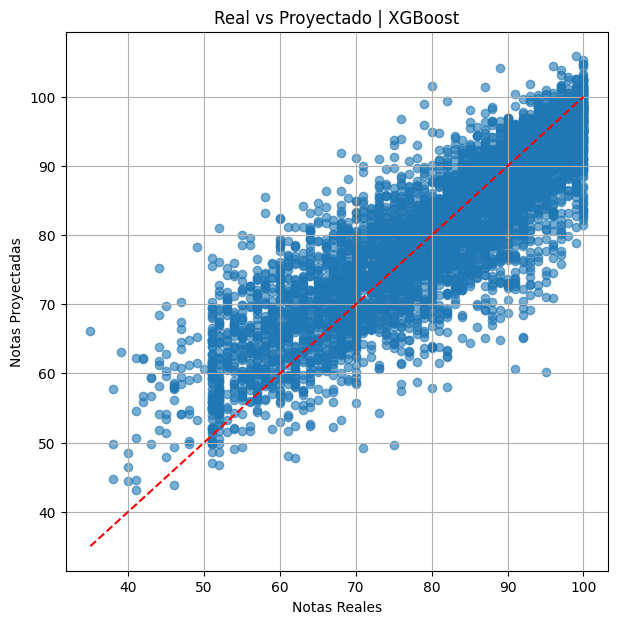

In [ ]:
# 3. Graficar Real vs Predicho

plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_test , alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Notas Reales")
plt.ylabel("Notas Proyectadas")
plt.title("Real vs Proyectado | XGBoost")
plt.grid(True)
plt.show()

In [ ]:
#Analisis por curso
# Recuperar los datos originales de df24 (curso, materia, nivel, etc.)
df_evalc = df24.loc[idx_test].copy()

df_evalc["nota_real"] = y_test
df_evalc["nota_pred"] = pred_test
metricas = []

for curso, grupo in df_evalc.groupby("curso"):
    real = grupo["nota_real"]
    pred = grupo["nota_pred"]

    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    r2 = r2_score(real, pred)

    metricas.append({
        "curso": curso,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

df_metricas = pd.DataFrame(metricas).sort_values("MAE")
df_metricas

,curso,MAE,RMSE,R²
9,3PRI B,3.147933,4.821420,0.637360
8,3PRI A,3.208603,4.919356,0.531097
5,2PRI B,3.377107,4.672353,0.751092
1,1PRI B,3.933166,5.003088,0.712222
13,4PRI B,4.407144,5.489890,0.781879
0,1PRI A,4.449850,5.741396,0.510107
20,6PRI A,4.610816,6.068872,0.759780
12,4PRI A,4.702703,6.022154,0.688783
16,5PRI A,4.759946,6.140160,0.761312
17,5PRI B,4.792383,6.212977,0.764708
